In [94]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

In [95]:
# Load cleaned dataset
df = pd.read_pickle('df_cleaned.pkl')

print(f"Dataset shape: {df.shape}")
print(f"\nAssuming first row of column info:")
print(df.head(3))

# Separate features and labels
if 'Label' in df.columns:
    X = df.drop('Label', axis=1)
    y = df['Label']
    print(f"\nLabel column found")
    print(f"Label distribution:")
    print(y.value_counts())
else:
    X = df
    y = None
    print("\nNo Label column found")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Dataset shape: (610794, 9)

Assuming first row of column info:
   Destination Port  Flow Duration  Fwd Packet Length Min  \
0                80          38308                      6   
1               389            479                      0   
2                88           1095                      0   

   Bwd Packet Length Max  Bwd Packet Length Min  Flow IAT Mean  Bwd IAT Std  \
0                      6                      6   38308.000000     0.000000   
1                    163                      0      31.933333   101.736178   
2                   1575                      0      73.000000   345.535092   

   Min Packet Length   Label  
0                  6  BENIGN  
1                  0  BENIGN  
2                  0  BENIGN  

Label column found
Label distribution:
Label
BENIGN              417035
DoS Hulk            172849
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Heartbleed              11
Name: count, dtype: int64

Feature matrix s

In [96]:
"""
DATA PREPROCESSING: SCALING
"""

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled Data Shape: {X_scaled.shape}")
print(f"Scaled Data Mean (≈0): {X_scaled.mean():.6f}")
print(f"Scaled Data Std (≈1): {X_scaled.std():.6f}")

Scaled Data Shape: (610794, 8)
Scaled Data Mean (≈0): -0.000000
Scaled Data Std (≈1): 1.000000


In [97]:
"""
DIMENSIONALITY REDUCTION: PCA
"""

# Automatic component selection
pca_full = PCA(n_components=0.95, whiten=True, random_state=42)
X_pca = pca_full.fit_transform(X_scaled)

print(f"\nPCA components retained: {X_pca.shape[1]}")
print(f"Total explained variance: {pca_full.explained_variance_ratio_.sum():.2%}")

# Scree plot (real one)
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_scree.png", dpi=120)
plt.close()

# 2D projection (visual only)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

explained_2d = pca_2d.explained_variance_ratio_
print(f"PCA 2D variance: {explained_2d.sum():.2%}")


PCA components retained: 7
Total explained variance: 97.41%
PCA 2D variance: 61.70%


In [98]:
"""
CLUSTERING: K-MEANS
"""

rng = np.random.default_rng(42)

# Sampling
n_samples = X_pca.shape[0]
sample_size = min(100000, n_samples)

idx = rng.choice(n_samples, sample_size, replace=False)
X_sample = X_pca[idx]

# Train / Eval split
eval_size = min(20000, sample_size // 3)

perm = rng.permutation(sample_size)
X_fit = X_sample[perm[:-eval_size]]
X_eval = X_sample[perm[-eval_size:]]

# Wider k search
k_values = range(2, 6)

results = []

print(f"K-Means Evaluation (fit={len(X_fit)}, eval={len(X_eval)}):")
print(f"{'k':<4} {'Sil':<8} {'DB':<8} {'Inertia':<12}")
print("-" * 45)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=20,
        max_iter=500,
        random_state=42
    )
    
    model.fit(X_fit)
    labels = model.predict(X_eval)

    sil = silhouette_score(X_eval, labels)
    db = davies_bouldin_score(X_eval, labels)

    results.append({
        "k": k,
        "model": model,
        "sil": sil,
        "db": db,
        "inertia": model.inertia_
    })

    print(f"{k:<4} {sil:<8.4f} {db:<8.4f} {model.inertia_:<12.2e}")

# Selection
df_k = pd.DataFrame(results)

kmeans_results = {
    row["k"]: {
        "model": row["model"],
        "sil": row["sil"],
        "db": row["db"],
        "inertia": row["inertia"],
        "silhouette": row["sil"],
        "davies_bouldin": row["db"]
    }
    for row in results
}

# Rule:
# 1. Max silhouette
# 2. Tie-break: lower DB
best = df_k.sort_values(
    by=["sil", "db"],
    ascending=[False, True]
).iloc[0]

optimal_k = int(best["k"])
best_model = best["model"]

kmeans_optimal_labels = best_model.predict(X_pca)

print(f"\nOptimal k: {optimal_k}")
print(f"Silhouette: {best['sil']:.4f}")
print(f"Davies-Bouldin: {best['db']:.4f}")
print(f"Inertia: {best['inertia']:.2e}")

K-Means Evaluation (fit=80000, eval=20000):
k    Sil      DB       Inertia     
---------------------------------------------
2    0.3293   0.9100   4.87e+05    
3    0.3928   1.2447   4.13e+05    
4    0.4637   1.0181   3.42e+05    
5    0.4660   0.8554   2.78e+05    

Optimal k: 5
Silhouette: 0.4660
Davies-Bouldin: 0.8554
Inertia: 2.78e+05


In [99]:
"""
K-MEANS EVALUATION METRICS
"""

# Sort safely
k_list = sorted(kmeans_results.keys())

# Build aligned arrays (robust)
inertias = [kmeans_results[k]["inertia"] for k in k_list]
silhouettes = [kmeans_results[k]["silhouette"] for k in k_list]
db_indices = [kmeans_results[k]["davies_bouldin"] for k in k_list]

# Best indices
best_sil_k = max(kmeans_results, key=lambda k: kmeans_results[k]["silhouette"])
best_db_k = min(kmeans_results, key=lambda k: kmeans_results[k]["davies_bouldin"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Inertia (Elbow)
axes[0].plot(k_list, inertias, marker='o')
axes[0].axvline(optimal_k, linestyle='--', label=f"k={optimal_k}")
axes[0].set_title("Elbow Method (Inertia)", fontweight='bold')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(k_list, silhouettes, marker='o')
axes[1].axvline(best_sil_k, linestyle='--', label=f"best={best_sil_k}")
axes[1].set_title("Silhouette Score", fontweight='bold')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Davies-Bouldin
axes[2].plot(k_list, db_indices, marker='o')
axes[2].axvline(best_db_k, linestyle='--', label=f"best={best_db_k}")
axes[2].set_title("Davies-Bouldin Index", fontweight='bold')
axes[2].set_xlabel("k")
axes[2].set_ylabel("Index (lower is better)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_evaluation.png", dpi=120, bbox_inches="tight")
plt.close()

print("K-Means evaluation metrics saved")

K-Means evaluation metrics saved


In [100]:
"""
HIERARCHICAL CLUSTERING
"""

linkage_criteria = ['ward', 'complete', 'average']

hc_results = {}

# Sampling
hc_sample_size = min(30000, X_pca.shape[0])
hc_idx = np.random.choice(X_pca.shape[0], hc_sample_size, replace=False)
X_hc_sample = X_pca[hc_idx]

print(f"\nHierarchical Clustering (sample={hc_sample_size}, k={optimal_k})")
print(f"{'Linkage':<10} {'Sil':<10} {'DB':<10}")
print("-" * 35)

# Fit + evaluate
for linkage in linkage_criteria:

    model = AgglomerativeClustering(
        n_clusters=optimal_k,
        linkage=linkage
    )

    labels = model.fit_predict(X_hc_sample)

    sil = silhouette_score(X_hc_sample, labels)
    db = davies_bouldin_score(X_hc_sample, labels)

    hc_results[linkage] = {
        "model": model,
        "labels": labels,
        "sil": sil,
        "db": db
    }

    print(f"{linkage:<10} {sil:<10.4f} {db:<10.4f}")

# Selection
best_linkage = max(
    hc_results,
    key=lambda k: (
        hc_results[k]["sil"] - hc_results[k]["db"]  # simple but stable trade-off
    )
)

best_hc_linkage = best_linkage
best_model = hc_results[best_linkage]["model"]
hc_optimal_labels = hc_results[best_linkage]["labels"]

# Propagate sample-based hierarchical labels to the full dataset for consistent visualization.
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_hc_sample, hc_optimal_labels)
hc_optimal_labels = knn.predict(X_pca)

print(f"\nBest linkage: {best_linkage}")
print(f"Silhouette: {hc_results[best_linkage]['sil']:.4f}")
print(f"Davies-Bouldin: {hc_results[best_linkage]['db']:.4f}")


Hierarchical Clustering (sample=30000, k=5)
Linkage    Sil        DB        
-----------------------------------
ward       0.4450     1.0442    
complete   0.7774     0.4590    
average    0.8193     0.4066    

Best linkage: average
Silhouette: 0.8193
Davies-Bouldin: 0.4066


In [101]:
"""
VISUALIZATION: Hierarchical Clustering
"""

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=hc_optimal_labels,
    cmap='viridis',
    s=20,
    alpha=0.75
)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')

ax.set_title(
    f'Hierarchical Clustering ({best_hc_linkage})\n'
    f'2D PCA projection of high-dimensional clusters',
    fontsize=12,
    fontweight='bold'
)

plt.colorbar(sc, ax=ax, label='Cluster ID')

plt.tight_layout()
plt.savefig('hierarchical_clustering.png', dpi=120, bbox_inches='tight')
plt.close()

print("Hierarchical clustering visualization saved")

Hierarchical clustering visualization saved


In [102]:
"""
DBSCAN CLUSTERING
"""

rng = np.random.default_rng(42)

sample_size = min(10000, X_pca.shape[0])
idx = rng.choice(X_pca.shape[0], sample_size, replace=False)
X_db = X_pca[idx]
y_db = y.iloc[idx] if y is not None else None

# k-distance for eps - use lower k for more connectivity
k = 5  
nn = NearestNeighbors(n_neighbors=k).fit(X_db)
distances, _ = nn.kneighbors(X_db)
k_dist = np.sort(distances[:, -1])

# Choose eps_values and min_samples 
eps_values = [1.2, 1.3, 1.4, 1.5]
min_samples_values = [15, 20, 25, 30]  # Lower than typical to allow more clusters in high dimensions

results = []

for eps in eps_values:
    for ms in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_db)

        # Calculate metrics

        # Number of clusters (excluding noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = np.mean(labels == -1)

        mask = labels != -1
        if np.sum(mask) < 10:
            continue

        sil = silhouette_score(X_db[mask], labels[mask])
        db = davies_bouldin_score(X_db[mask], labels[mask])

        results.append([eps, ms, n_clusters, noise, sil, db])

        print(f"eps={eps:.3f} min_samples={ms:<3} clusters={n_clusters:<3} noise={noise:.2%} sil={sil:.3f} db={db:.3f}")

df = pd.DataFrame(results, columns=["eps","min_samples","clusters","noise","sil","db"])

# Prefer lower-noise options with a reasonable number of clusters
df_valid = df[
    (df["noise"].between(0.05, 0.50)) &
    (df["clusters"].between(2, 5))
]

if len(df_valid) == 0:
    df_valid = df

best_dbscan = df_valid.sort_values(
    by=["noise", "sil", "db"],  # Prioritize low noise, then high silhouette, then low DB
    ascending=[True, False, True]
).iloc[0]

best_eps, best_ms = best_dbscan["eps"], int(best_dbscan["min_samples"])
best_min_samples = best_ms

# Fit the best DBSCAN model on the sampled data and keep the same 2D PCA projection.
dbscan_optimal_labels = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit_predict(X_db)
X_pca_2d_db = X_pca_2d[idx]

n_dbscan_clusters = len(set(dbscan_optimal_labels)) - (1 if -1 in dbscan_optimal_labels else 0)
n_dbscan_noise = np.sum(dbscan_optimal_labels == -1)

# Propagate DBSCAN labels to full dataset
knn_db_full = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_db_full.fit(X_db, dbscan_optimal_labels)
dbscan_full_labels = knn_db_full.predict(X_pca)

n_dbscan_full_clusters = len(set(dbscan_full_labels)) - (1 if -1 in dbscan_full_labels else 0)

n_dbscan_full_noise = np.sum(dbscan_full_labels == -1)

print(f"sample clusters={n_dbscan_clusters}, sample noise={n_dbscan_noise/len(dbscan_optimal_labels):.1%}")
print(f"full clusters={n_dbscan_full_clusters}, full noise={n_dbscan_full_noise/len(dbscan_full_labels):.1%}")

print(f"\nBEST DBSCAN: eps={best_eps:.3f}, min_samples={best_min_samples}")

eps=1.200 min_samples=15  clusters=3   noise=1.26% sil=0.442 db=0.497
eps=1.200 min_samples=20  clusters=2   noise=1.48% sil=0.442 db=0.589
eps=1.200 min_samples=25  clusters=3   noise=1.51% sil=0.399 db=0.680
eps=1.200 min_samples=30  clusters=3   noise=1.66% sil=0.368 db=0.676
eps=1.300 min_samples=15  clusters=4   noise=1.07% sil=0.437 db=0.484
eps=1.300 min_samples=20  clusters=2   noise=1.39% sil=0.442 db=0.589
eps=1.300 min_samples=25  clusters=2   noise=1.40% sil=0.442 db=0.589
eps=1.300 min_samples=30  clusters=2   noise=1.53% sil=0.443 db=0.588
eps=1.400 min_samples=15  clusters=3   noise=1.03% sil=0.440 db=0.499
eps=1.400 min_samples=20  clusters=2   noise=1.27% sil=0.441 db=0.590
eps=1.400 min_samples=25  clusters=2   noise=1.27% sil=0.441 db=0.590
eps=1.400 min_samples=30  clusters=2   noise=1.29% sil=0.441 db=0.590
eps=1.500 min_samples=15  clusters=3   noise=0.85% sil=0.439 db=0.500
eps=1.500 min_samples=20  clusters=2   noise=1.14% sil=0.440 db=0.591
eps=1.500 min_sample

In [103]:
"""
BUILD COMPARISON TABLE
"""

# Safe extraction

# K-Means
kmeans_info = kmeans_results.get(optimal_k)

if kmeans_info is None and 'df_k' in globals():
    km_row = df_k.loc[df_k['k'] == optimal_k]
    if len(km_row) == 1:
        kmeans_info = {
            "sil": km_row.iloc[0]["sil"],
            "db": km_row.iloc[0]["db"],
            "silhouette": km_row.iloc[0]["sil"],
            "davies_bouldin": km_row.iloc[0]["db"]
        }

if kmeans_info is None:
    kmeans_info = {"sil": np.nan, "db": np.nan}
kmeans_sil = kmeans_info.get("sil", kmeans_info.get("silhouette", np.nan))
kmeans_db = kmeans_info.get("db", kmeans_info.get("davies_bouldin", np.nan))

# Hierarchical
hc_sil = hc_results[best_hc_linkage]["sil"]
hc_db = hc_results[best_hc_linkage]["db"]

# DBSCAN
# Use the already computed sample-based DBSCAN metrics instead of expensive full-data recomputation.
dbscan_labels = dbscan_full_labels

dbscan_sil = float(best_dbscan["sil"]) if "best_dbscan" in globals() else np.nan
dbscan_db = float(best_dbscan["db"]) if "best_dbscan" in globals() else np.nan

dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Build table
comparison_df = pd.DataFrame({
    "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
    "Parameters": [
        f"k={optimal_k}",
        f"linkage={best_hc_linkage}",
        f"eps={best_eps:.3f}, min_samples={best_min_samples}"
    ],
    "N_Clusters": [
        optimal_k,
        optimal_k,
        dbscan_clusters
    ],
    "Silhouette": [
        kmeans_sil,
        hc_sil,
        dbscan_sil
    ],

    "Davies-Bouldin": [
        kmeans_db,
        hc_db,
        dbscan_db
    ]
})

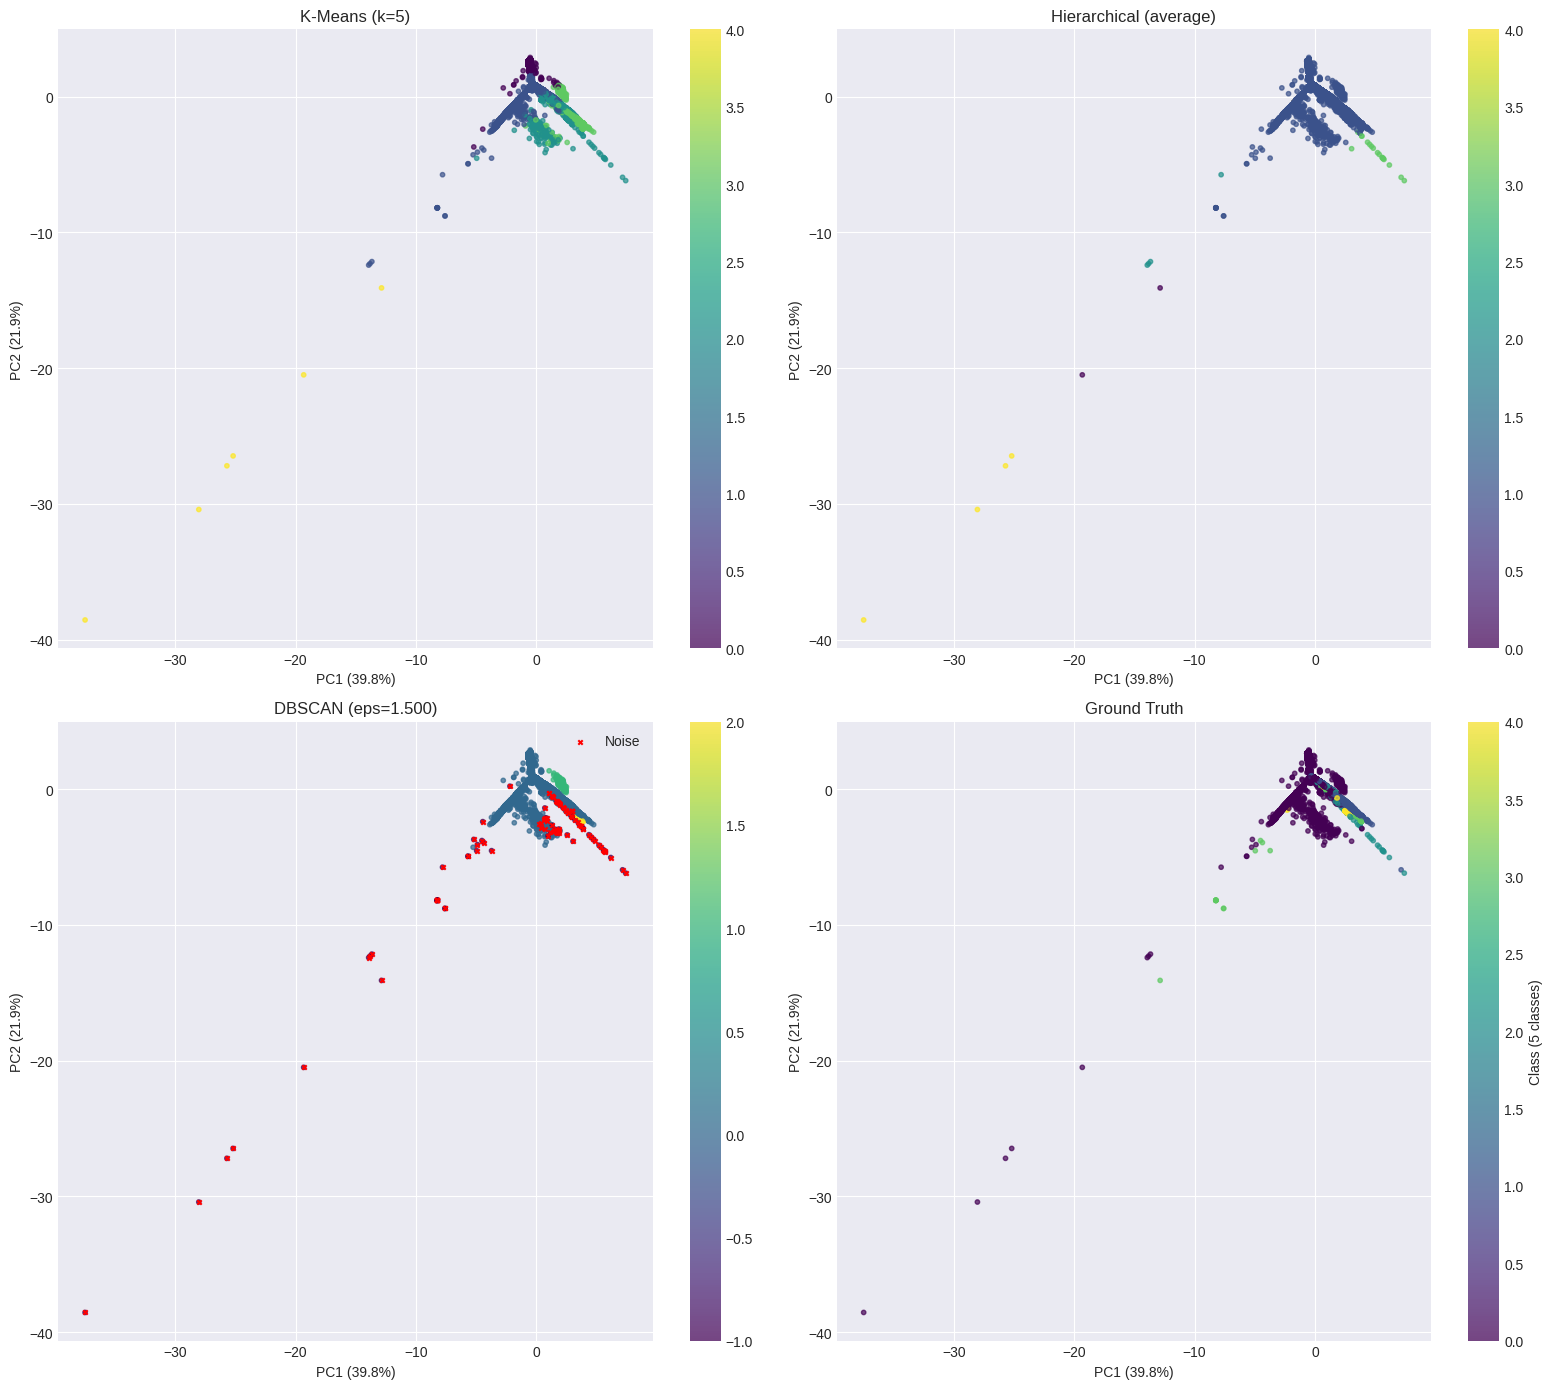

In [104]:
"""
VISUALIZATION: 4-Panel Comparison
"""

# For consistent visualization, use the same sample for all algorithms
viz_sample_size = min(15000, X_pca.shape[0])  # Reasonable size for visualization
viz_rng = np.random.default_rng(123)  # Different seed for viz sample
viz_idx = viz_rng.choice(X_pca.shape[0], viz_sample_size, replace=False)
X_pca_2d_viz = X_pca_2d[viz_idx]

# Get labels for the visualization sample
kmeans_viz_labels = kmeans_optimal_labels[viz_idx]
hc_viz_labels = hc_optimal_labels[viz_idx]

# Use full DBSCAN propagation labels for visualization
dbscan_viz_labels = dbscan_full_labels[viz_idx]

# Ground truth for visualization sample
if y is not None:
    y_viz = y.iloc[viz_idx] if hasattr(y, 'iloc') else y[viz_idx]
    y_viz_enc, _ = pd.factorize(y_viz)
    n_classes = len(np.unique(y_viz_enc))
else:
    y_viz_enc = None

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

pca_var1 = pca_2d.explained_variance_ratio_[0]
pca_var2 = pca_2d.explained_variance_ratio_[1]

# K-MEANS
sc1 = axes[0, 0].scatter(
    X_pca_2d_viz[:, 0],
    X_pca_2d_viz[:, 1],
    c=kmeans_viz_labels,
    cmap='viridis',
    s=10,
    alpha=0.7
)

axes[0, 0].set_title(f"K-Means (k={optimal_k})")
axes[0, 0].set_xlabel(f"PC1 ({pca_var1:.1%})")
axes[0, 0].set_ylabel(f"PC2 ({pca_var2:.1%})")
plt.colorbar(sc1, ax=axes[0, 0])

# HIERARCHICAL
sc2 = axes[0, 1].scatter(
    X_pca_2d_viz[:, 0],
    X_pca_2d_viz[:, 1],
    c=hc_viz_labels,
    cmap='viridis',
    s=10,
    alpha=0.7
)

axes[0, 1].set_title(f"Hierarchical ({best_hc_linkage})")
axes[0, 1].set_xlabel(f"PC1 ({pca_var1:.1%})")
axes[0, 1].set_ylabel(f"PC2 ({pca_var2:.1%})")
plt.colorbar(sc2, ax=axes[0, 1])

# DBSCAN
sc3 = axes[1, 0].scatter(
    X_pca_2d_viz[:, 0],
    X_pca_2d_viz[:, 1],
    c=dbscan_viz_labels,
    cmap='viridis',
    s=10,
    alpha=0.7
)

noise_mask = dbscan_viz_labels == -1
axes[1, 0].scatter(
    X_pca_2d_viz[noise_mask, 0],
    X_pca_2d_viz[noise_mask, 1],
    c='red',
    s=10,
    marker='x',
    label='Noise'
)

axes[1, 0].set_title(f"DBSCAN (eps={best_eps:.3f})")
axes[1, 0].set_xlabel(f"PC1 ({pca_var1:.1%})")
axes[1, 0].set_ylabel(f"PC2 ({pca_var2:.1%})")
axes[1, 0].legend()
plt.colorbar(sc3, ax=axes[1, 0])

# GROUND TRUTH
if y_viz_enc is not None:
    sc4 = axes[1, 1].scatter(
        X_pca_2d_viz[:, 0],
        X_pca_2d_viz[:, 1],
        c=y_viz_enc,
        cmap='viridis',
        s=10,
        alpha=0.7,
        vmin=0,
        vmax=n_classes-1
    )

    axes[1, 1].set_title("Ground Truth")
    axes[1, 1].set_xlabel(f"PC1 ({pca_var1:.1%})")
    axes[1, 1].set_ylabel(f"PC2 ({pca_var2:.1%})")
    cbar = plt.colorbar(sc4, ax=axes[1, 1])
    cbar.set_label(f"Class ({n_classes} classes)")
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig("algorithms_comparison.png", dpi=120)
plt.show()

In [105]:
"""
EXTERNAL VALIDATION: Compare with Ground Truth
"""

if y is not None:

    # Align all predictions
    y_true = y  # MUST match all model outputs

    k_pred = kmeans_optimal_labels
    h_pred = hc_optimal_labels
    d_pred = dbscan_full_labels

    # Metrics
    ext = pd.DataFrame({
        "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
        "ARI": [
            adjusted_rand_score(y_true, k_pred),
            adjusted_rand_score(y_true, h_pred),
            adjusted_rand_score(y_true, d_pred)
        ],

        "NMI": [
            normalized_mutual_info_score(y_true, k_pred),
            normalized_mutual_info_score(y_true, h_pred),
            normalized_mutual_info_score(y_true, d_pred)
        ]
    })

    print(ext.to_string(index=False))

    # Contingency tables
    print("\nK-Means vs Ground Truth")
    print(pd.crosstab(y_true, k_pred))

    print("\nHierarchical vs Ground Truth")
    print(pd.crosstab(y_true, h_pred))

    print("\nDBSCAN vs Ground Truth")
    print(pd.crosstab(y_true, d_pred))
else:
    print("\nNo ground truth labels available for external validation.")


   Algorithm      ARI      NMI
     K-Means 0.297702 0.269877
Hierarchical 0.005219 0.013332
      DBSCAN 0.019326 0.053389

K-Means vs Ground Truth
col_0                 0       1      2      3    4
Label                                             
BENIGN            70854  298072  42638   5188  283
DoS GoldenEye         0    8679   1601      6    0
DoS Hulk              0   32138  95650  45061    0
DoS Slowhttptest      0    1145   2918   1123   42
DoS slowloris         0    2230   1287   1868    0
Heartbleed            0       1     10      0    0

Hierarchical vs Ground Truth
col_0               0       1    2    3    4
Label                                       
BENIGN            163  416372  220  165  115
DoS GoldenEye       0    9479    0  807    0
DoS Hulk            0  172845    3    1    0
DoS Slowhttptest   42    5185    1    0    0
DoS slowloris       0    5385    0    0    0
Heartbleed          0      11    0    0    0

DBSCAN vs Ground Truth
col_0               -1       

In [106]:
"""
SUMMARY REPORT
"""

best_sil_algo = comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Algorithm']
best_sil_val = comparison_df['Silhouette'].max()
best_db_algo = comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin(), 'Algorithm']
best_db_val = comparison_df['Davies-Bouldin'].min()

print(f"""
DATA & PCA:
  • Samples: {X_scaled.shape[0]:,}, Features: {X_scaled.shape[1]}
  • PCA (Full): {X_pca.shape[1]} components
  • PCA 2D Variance: {pca_2d.explained_variance_ratio_.sum():.2%}

K-MEANS (k={optimal_k}):
  • Silhouette: {comparison_df.loc[0, 'Silhouette']:.4f}
  • Davies-Bouldin: {comparison_df.loc[0, 'Davies-Bouldin']:.4f}

HIERARCHICAL ({best_hc_linkage}):
  • Silhouette: {comparison_df.loc[1, 'Silhouette']:.4f}
  • Davies-Bouldin: {comparison_df.loc[1, 'Davies-Bouldin']:.4f}

DBSCAN (eps={best_eps:.3f}, min_samples={best_min_samples}):
  • Clusters: {n_dbscan_full_clusters}
  • Noise: {n_dbscan_full_noise} ({n_dbscan_full_noise/len(dbscan_full_labels)*100:.1f}%)
  • Silhouette: {comparison_df.loc[2, 'Silhouette']:.4f}
  • Davies-Bouldin: {comparison_df.loc[2, 'Davies-Bouldin']:.4f}

BEST PERFORMERS:
  • By Silhouette: {best_sil_algo} ({best_sil_val:.4f})
  • By Davies-Bouldin: {best_db_algo} ({best_db_val:.4f})
""")


DATA & PCA:
  • Samples: 610,794, Features: 8
  • PCA (Full): 7 components
  • PCA 2D Variance: 61.70%

K-MEANS (k=5):
  • Silhouette: 0.4660
  • Davies-Bouldin: 0.8554

HIERARCHICAL (average):
  • Silhouette: 0.8193
  • Davies-Bouldin: 0.4066

DBSCAN (eps=1.500, min_samples=15):
  • Clusters: 3
  • Noise: 4983 (0.8%)
  • Silhouette: 0.4392
  • Davies-Bouldin: 0.5000

BEST PERFORMERS:
  • By Silhouette: Hierarchical (0.8193)
  • By Davies-Bouldin: Hierarchical (0.4066)

